# Tools to programmatically access real-time oceanographic data 

This coding workbook will demonstrate how to use ERDDAP to programmatically access oceanographic data. We will use real data from sensors located in the Barkley Sound Region. Here, we will use ERDDAP data servers to access O2 data collected by Ocean Networks Canada at the [China Creek Observatory](https://data.oceannetworks.ca/Dashboards/id/175) located near the head of the Alberni Inlet. These data, among others in the region, are discoverable through [CIOOS Data Explorer](https://explore.cioos.ca/?lang=en) and [CIOOS Data Catalogue](https://catalogue.cioos.ca/). 

# Part I: Understanding ERDDAP servers 

[ERDDAP (Environmental Research Division Data Access Program)](https://coastwatch.noaa.gov/erddap/information.html) is a public access data server/software that acts as an intermediary between users and remote data sources. The ERDDAP processes requests from users, pulls data from data sources, reformats the data according to user preference, and sends it to the user. ERDDAP was originally developed by NOAA to serve oceanographic data, but any organization or individual can create their own ERDDAP server using available [code packages](https://erddap.github.io/docs/server-admin/deploy-install). The beauty of ERDDAP is that it can use information stored in metadata files to convert data to any one of 30+ supported formats you might request (e.g. csv, html table, mat, etc). ERDDAP was initially designed to make diverse datasets more comparable, so space/time variables are always standardized: 

* **longitude** is always in degrees_east. 
* **latitude** is always in degrees_north. 
* **altitude** is always in meters with positive=up. 
* **depth** is always in meters with positive=down. 
* **time**, when formatted as a number, is always in "seconds since 1970-01-01T00:00:00Z" (known as Unix time) and, when formatted as a string, is formatted according to the ISO 8601 standard (yyyy-MM-ddTHH:mm:ssZ). 

ERDDAP enables data access through a specifically formatted query URL. The ERDDAP web page interface you can interact with allows you to set your filter parameters, and then it will automatically produce the query URL for you. If you copy and paste this URL in your browser, it will initiate data download. These query URLs have a standardized structure. Once you understand the structure, you can programmatically access data through your favorite coding software (MATLAB, python, R) without ever needing to visit the ERDDAP web page.


## Using ERDDAP to programmatically access ONC data

In this example, we will use [Ocean Networks Canada's ERDDAP](https://dap.oceannetworks.ca/erddap/index.html) to programmatically access data collected by in-situ sensors. You will see all ERDDAPs segregate data into either `griddap` or `tabledap` datasets. Multidimensional gridded data is available from `griddap`, while one-to-two dimensional data (e.g., buoy data) is available from `tabledap`. 

We can use the standardized url structure to generate the url. The code below shows how the URL is constructed to pull China Creek O2 data. How would you modify the code to access different ONC datasets?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import urllib.parse
import time
import requests
import io

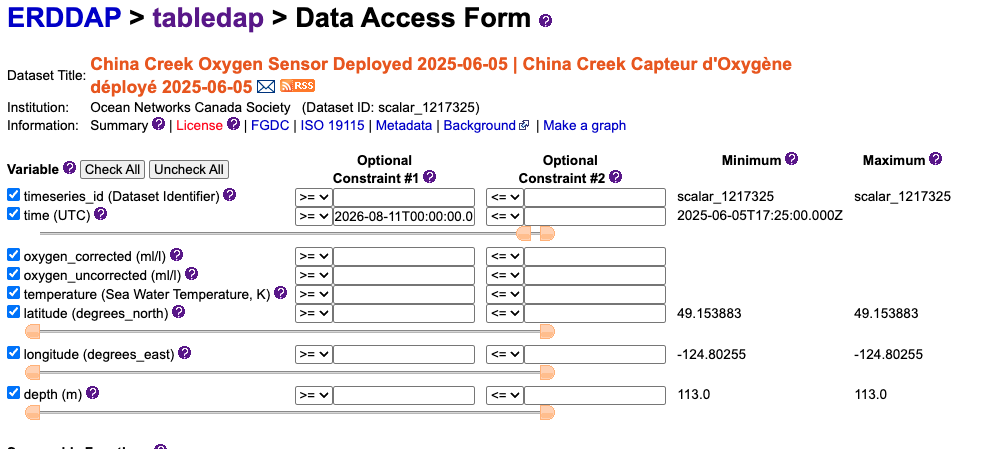

#### Constructing our ERDDAP URL
In the cell below, we will construct our ERDDAP URL, based on the info in the screenshot of ONC's ERDDAP page above, fill in the missing elements of the ERDDAP URL 

In [ ]:
# Set the time range
time_series_length = 14 # in days. note ERDDAP server is slow, which is why we are limiting to 14 days for now. 
start_time = time.strftime("%Y-%m-%dT%H:%M:%S.000Z",time.gmtime(time.time() - time_series_length*24*3600)) 
              
# Constructing our data query url. 
onc_erddap = 'https://dap.oceannetworks.ca/erddap/tabledap/'
dataset_id = 'scalar_1217325' # Update with different dataset IDs to plot other ONC data
format_ext = '.csv' 
query_vars = 'time,temperature,oxygen_corrected,oxygen_uncorrected,latitude,longitude,depth' 

# Create url by concatenating query elements according to url structure
url = f"{onc_erddap}{dataset_id}{format_ext}?{query_vars}&time>={start_time}" # Remove time constraint to download full dataset
print(f"Querying data from: {url}")

Querying data from: https://dap.oceannetworks.ca/erddap/tabledap/scalar_1217325.csv?time,temperature,oxygen_corrected,oxygen_uncorrected,latitude,longitude,depth&time>=2026-08-03T22:26:37.000Z


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'dap.oceannetworks.ca'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/var/folders/6y/jz4t2xyn6n99xnshsh1vq6gw0000gq/T/ipykernel_30112/472824068.py:19: DtypeWarning: Columns (0: temperature, 1: oxygen_corrected, 2: oxygen_uncorrected, 3: latitude, 4: longitude, 5: depth) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(io.StringIO(response.text))


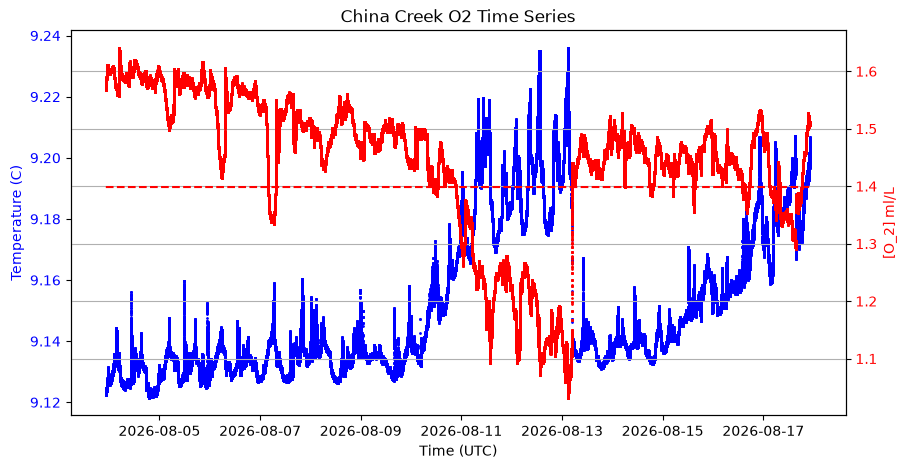

In [11]:
# Download the full dataset
response = requests.get(url, verify=False)
response.raise_for_status()

data = pd.read_csv(io.StringIO(response.text))

# The first row of an ERDDAP CSV response contains the units
units = data.iloc[0]
data_values = data.iloc[1:].copy()

# Convert time column to datetime objects
data_values['time'] = pd.to_datetime(data_values['time'])
data_values['temperature'] = pd.to_numeric(data_values['temperature']) - 273.15 # convert from K to celsius
data_values['oxygen_corrected'] = pd.to_numeric(data_values['oxygen_corrected'])

# Plot time series 

fig, ax1 = plt.subplots(figsize=(10, 5))
line1, = ax1.plot(data_values['time'], data_values['temperature'], 'b.',markersize=2)
ax1.set_xlabel('Time (UTC)')
ax1.set_ylabel('Temperature (C)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
line2, = ax2.plot(data_values['time'], data_values['oxygen_corrected'], 'r.',markersize=2)
ax2.set_ylabel('[O_2] ml/L', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Plot the the threshold for hypoxia (< 2 mg O2/L) - convert to mL/L 
line3, = ax2.plot(data_values['time'], 2/1.43*np.ones(np.size(data_values['time'])), 'r--')

plt.title('China Creek O2 Time Series')
plt.grid(True)
plt.show()

# note, if you get a CertVerification error, you need to configure your python's certificate verification
# To fix: Open your python folder in your applications folder, double click the file labeled Install Certificates.command and rerun the code

### Dynamic data access

If you are interested in a one-time data download, this programmatic approach is not the most straightforward. The utility of these approaches is being able to use code to dynamically update URLs and access live data that updates on a regular basis (e.g. satellite data or weather model data). 

Below we will use a more dynamic approach than the one above to access *new* data since our most recent call and append our growing data file.

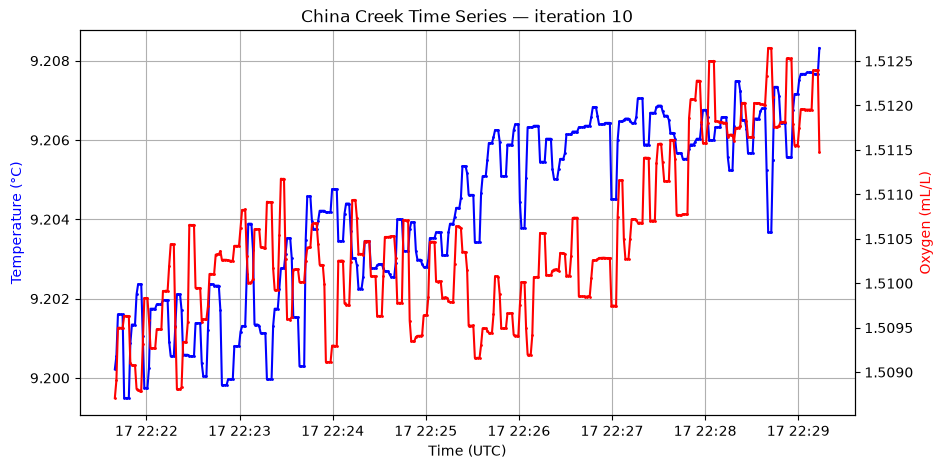

In [12]:
# Request new data from ERDDAP every minute and append it
poll_interval = 10 # seconds between polls (adjust as needed)
max_iterations = 10 # safety limit to avoid infinite loops (adjust as needed)

# Create a new plot zooming in on the most data collection
last_hr = data_values[data_values['time'] > pd.Timestamp.now('UTC') - pd.Timedelta(hours=0.10)]

fig, ax1 = plt.subplots(figsize=(10, 5))
line1, = ax1.plot(last_hr['time'], last_hr['temperature'], 'b.-', markersize=2)
ax1.set_xlabel('Time (UTC)')
ax1.set_ylabel('temperature (C)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
line2, = ax2.plot(last_hr['time'], last_hr['oxygen_corrected'], 'r.-', markersize=2)
ax2.set_ylabel('Oxygen (mL/L)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('China Creek Time Series')
plt.grid(True)
plt.show(block=False)

for i in range(max_iterations):
    # Update latestDate and updateUrl for next poll
    latest_date = last_hr['time'].iloc[-1].strftime("%Y-%m-%dT%H:%M:%S.%fZ")
    update_url = f"{onc_erddap}{dataset_id}{format_ext}?{query_vars}&time>={latest_date}" # Query data since last retreived datapoint 

    try:
        response = requests.get(update_url, timeout=120)
        response.raise_for_status()
        new_data = pd.read_csv(io.StringIO(response.text))
    except Exception as e:
        print(f"Failed to read update_url: {e}\nRetrying after {poll_interval} seconds...")
        time.sleep(poll_interval)
        continue

    # If only header returned or no rows
    if new_data.empty or len(new_data) <= 1:
        time.sleep(poll_interval)
        continue

    # Extract values
    new_values = new_data.iloc[1:].copy()
    new_values['time'] = pd.to_datetime(new_values['time'])
    new_values['temperature'] = pd.to_numeric(new_values['temperature']) - 273.15 # convert from kelvin to C
    new_values['oxygen_corrected'] = pd.to_numeric(new_values['oxygen_corrected'])

    # Append to existing data variables
    last_hr = pd.concat([last_hr, new_values], ignore_index=True)

    print(f"Iteration {i+1}: Successfully appended {len(new_values)} new rows.")

    # Make a NEW figure

    clear_output(wait=True)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(
        last_hr['time'],
        last_hr['temperature'],
        'b.-',
        markersize=2
    )

    ax1.set_xlabel('Time (UTC)')
    ax1.set_ylabel('Temperature (°C)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()

    ax2.plot(
        last_hr['time'],
        last_hr['oxygen_corrected'],
        'r.-',
        markersize=2
    )

    ax2.set_ylabel('Oxygen (mL/L)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax1.set_title(f'China Creek Time Series — iteration {i+1}')
    ax1.grid(True)
    plt.tight_layout
    plt.show()
    # Wait for the next ERDDAP request
    time.sleep(poll_interval)

# Bonus Part!! 
## Creating an online data dashboard

Please only complete this section if you have extra time in the workshop or during post-workshop time. 

This section will walk through using ERDDAP data access protocols and a package called `streamlit` to create an online data dashboard. `streamlit` enables developers to create interactive online data apps in python without writing javascript or HTML code. 

Although we are writing the code to run our dashboard within this notebook, the dashboard code is run independently from the cells above. As a result, variables defined in the cells above will not be transferred to the dashboard and will need to be redefined in the dashboard code. This means we will have to recreate our ERDDAP data call within the dashboard code. Now that you have experience writing an ERDDAP URL, this section of the code has been left blank for you to fill in yourself!


In [13]:
%pip show streamlit 

# If not installed, you will get a response: WARNING: Package(s) not found: streamlit
# Note: you may need to restart the kernel to use updated packages.

# If not installed run the cell below. If installed you may skip it. 

Note: you may need to restart the kernel to use updated packages.


In [41]:
%pip show plotly

# If not installed, you will get a response: WARNING: Package(s) not found: plotly
# Note: you may need to restart the kernel to use updated packages.

# If not installed run the cell below. If installed you may skip it. 

Name: plotly
Version: 6.9.0
Summary: An open-source interactive data visualization library for Python
Home-page: https://plotly.com/python/
Author: 
Author-email: Chris P <chris@plot.ly>
License-Expression: MIT
Location: /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages
Requires: narwhals, packaging
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Skip if streamlit already installed.
%pip install streamlit

In [ ]:
# Skip if streamlit already installed.
%pip install plotly

In [24]:
import streamlit as st

## Writing the dashboard code
The code that creates the dashboard will be run from an independent .py file. 
We will create and write that .py file here within this notebook in the cell below.

To start let's keep it simple and let's just give the dashboard a name, 'China Creek Ocean Conditions', and a message, 'Hello from our ERDDAP dashbaord'.

In [20]:
# Creating the dashboard script
from pathlib import Path

dashboard_code = """
import streamlit as st

st.title("China Creek Ocean Conditions")

st.write("Hello from our ERDDAP dashboard!")
"""

dashboard_path = Path("china_creek_dashboard.py")
dashboard_path.write_text(dashboard_code)

print(f"Dashboard file created: {dashboard_path.resolve()}")

Dashboard file created: /Users/yaylasezginer/Documents/github/ohw-tutorials/01-Tue/china_creek_dashboard.py


### Check the new file

Look at your jupyter hub home, do you see a new file there? Check its contents, does it match what we wrote in the cell above?

In [21]:
# What is in the new py file? 
print(dashboard_path.read_text())


import streamlit as st

st.title("China Creek Ocean Conditions")

st.write("Hello from our ERDDAP dashboard!")



### Launch the dashboard

Now we have a .py file that will create our online dashboard. They dashboard will not exist until we execute that .py file. To launch our new dashbaord, execute the .py file in terminal. 
1. Open a new terminal shell separete from the one running this notebook
2. Ensure the working directory matches the current project directory
3. Run the following line: streamlit run china_creek_dashboard.py

You should see something like, "Local URL: http://localhost:8501" returned. 
This is the url of the dashboard. Copy and paste into your web browser. 

### Updating the dashboard code

The dashboard code is currently pretty empty. Here, we will rewrite the china_creek_dashboard.py code we defined above as 'dashboard_code'. The code we write here will be very similar to what we wrote above in cell 2 and 3 of this notebook. Our workflow will be:
1. Create a function to iteratively retrieve data from the ERDDAP and update figure
2. Set up the dashboard
3. Create a static figure placeholder with three traces: O2, temperature, and our hypoxia threshold line
4. Call the function created in step 1

Everything has been filled in for you, except the part of the function where we define the ERDDAP url. Use the example from Cell 2 and 3 to complete this part on your own. To update the dashboard, run the cell below and then refresh your dashboard page. 
Note: A function can be defined at any time, the important thing is where/when the function is *called* within the code. I placed the function at the top so it would be easier to find the section where we define the ERDDAP url that you need to edit. 

In [40]:
# Add dynamic ERDDAP data plotting to our dashboard code.

from pathlib import Path

dashboard_code = """
import streamlit as st
import pandas as pd
import requests
import io
import time
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. Function to retrieve and update the data
# ---------------------------------------------------------

@st.fragment(run_every="10s")
def update_dashboard():

    # -----------------------------------------------------
    # Set the time range for the initial request
    # -----------------------------------------------------

    time_series_length = 1  # days, restricted to 1 because ERDDAP is slow

    start_time = time.strftime("%Y-%m-%dT%H:%M:%S.000Z", time.gmtime(time.time() - time_series_length * 24 * 3600))

    # -----------------------------------------------------
    # Construct ERDDAP URL <----- YOUR EDITS HERE
    # -----------------------------------------------------

    XXX
    
    url = (f"{onc_erddap}{dataset_id}{format_ext}?{query_vars}&time>={start_time}")

    # -----------------------------------------------------
    # Get data from ERDDAP
    # -----------------------------------------------------

    try:

        response = requests.get(url, verify=False,timeout=120)
        response.raise_for_status()
        data = pd.read_csv(io.StringIO(response.text))

    except Exception as e:
        st.error(f"Unable to retrieve ERDDAP data: {e}")
        return

    # -----------------------------------------------------
    # Process ERDDAP data
    # -----------------------------------------------------

    # First row contains units
    data_values = data.iloc[1:].copy()

    data_values["time"] = pd.to_datetime(data_values["time"])
    data_values["temperature"] = (pd.to_numeric(data_values["temperature"]) - 273.15)
    data_values["oxygen_corrected"] = pd.to_numeric(data_values["oxygen_corrected"])

    # Sort by time
    data_values = data_values.sort_values("time").reset_index(drop=True)

    # -----------------------------------------------------
    # Determine which data are new
    # -----------------------------------------------------

    if st.session_state.last_time is None:

        # First request: use all available data
        new_values = data_values.copy()

    else:

        # Subsequent requests: only use observations from latest call
        new_values = data_values[data_values["time"] > st.session_state.last_time].copy()

    # -----------------------------------------------------
    # Add new observations to the existing plot
    # -----------------------------------------------------

    if not new_values.empty:

        st.session_state.plot_data = pd.concat(
            [st.session_state.plot_data, new_values[
                ["time", "temperature", "oxygen_corrected"]
            ]], ignore_index=True)

        # Remove duplicate observations
        st.session_state.plot_data = (
            st.session_state.plot_data
            .drop_duplicates(subset="time")
            .sort_values("time")
            .reset_index(drop=True)
        )

        # Update most recent timestamp
        st.session_state.last_time = (new_values["time"].max())

        # -------------------------------------------------
        # Update the existing Plotly traces
        # -------------------------------------------------

        fig = st.session_state.plot_fig

        plot_data = st.session_state.plot_data

        # Temperature trace
        fig.data[0].x = plot_data["time"]
        fig.data[0].y = plot_data["temperature"]

        # Oxygen trace
        fig.data[1].x = plot_data["time"]
        fig.data[1].y = plot_data["oxygen_corrected"]

        # Hypoxia threshold
        fig.data[2].x = [plot_data["time"].min(),plot_data["time"].max()]
        fig.data[2].y = [2 / 1.43, 2 / 1.43]

        # Save the updated figure
        st.session_state.plot_fig = fig

    # -----------------------------------------------------
    # Update latest-value displays
    # -----------------------------------------------------

    if not data_values.empty:

        latest = data_values.iloc[-1]

        temperature_display.metric("Temperature", f"{latest['temperature']:.4f} °C")
        oxygen_display.metric("Oxygen", f"{latest['oxygen_corrected']:.4f} mL/L")
        depth_display.metric("Depth", f"{float(latest['depth']):.1f} m")

        st.caption(f"Most recent observation: {latest['time']} UTC")
        st.caption(f"ERDDAP Query: {url}")

        plot_placeholder.plotly_chart(st.session_state.plot_fig,
            use_container_width=True, key="china_creek_plot")

        # End of function update_dashboard

# ---------------------------------------------------------
# 2. Dashboard settings
# ---------------------------------------------------------

st.set_page_config(page_title="China Creek Ocean Conditions",layout="wide")

st.title("China Creek Ocean Conditions")

col1, col2, col3 = st.columns(3)

temperature_display = col1.empty()
oxygen_display = col2.empty()
depth_display = col3.empty()

plot_placeholder = st.empty()

# ---------------------------------------------------------
# 3. Create the plot ONCE
# ---------------------------------------------------------

if "plot_fig" not in st.session_state:

    fig = go.Figure()

    # Temperature trace
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            name="Temperature",
            mode="lines+markers",
            marker=dict(size=4),
            line=dict(color="blue"),
            yaxis="y1",
            showlegend=True
        )
    )

    # Oxygen trace
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            name="Oxygen",
            mode="lines+markers",
            marker=dict(size=4),
            line=dict(color="red"),
            yaxis="y2",
            showlegend=True
        )
    )

    # Hypoxia threshold
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            name="Hypoxia threshold",
            mode="lines",
            line=dict(dash="dash",color="red"),
            yaxis="y2",
            showlegend=True
        )
    )

    # Figure layout function
    fig.update_layout(

        title="China Creek O₂ Time Series",

        xaxis=dict(title="Time (UTC)"),
        yaxis=dict(title="Temperature (°C)",side="left"),
        yaxis2=dict(title="Oxygen (mL/L)",side="right",overlaying="y"),

        hovermode="x unified",

        height=550,

        # Keep the Plotly chart from resetting 
        uirevision="china-creek"
    )

    st.session_state.plot_fig = fig

    # Store all observations used by the plot
    st.session_state.plot_data = pd.DataFrame(columns=["time","temperature","oxygen_corrected"])

    # Keep track of the most recent observation
    st.session_state.last_time = None

# ---------------------------------------------------------
# Start the dashboard
# ---------------------------------------------------------

update_dashboard()
"""

dashboard_path = Path("china_creek_dashboard.py")
dashboard_path.write_text(dashboard_code)

print(f"Dashboard updated: {dashboard_path.resolve()}")

Dashboard updated: /Users/yaylasezginer/Documents/github/ohw-tutorials/01-Tue/china_creek_dashboard.py


### Modifying our code to improve plotting speed. 

Notice how slowly the dashboard is plotting? Why might that be? How can we improve the plotting speed?

Hint: What do we know about the speed of data extraction from ERDDAP?
Look at our original notebook Cells 2 & 3, how much data do we initially extract vs. how much do we extract in each loop iteration? How can we modify our code above to only pull *new* data from the ERDDAP rather than pulling a full 24 hrs worth of data each run?

In [45]:
# Add incremental ERDDAP data requests to our dashboard code.

from pathlib import Path

dashboard_code = """
import streamlit as st
import pandas as pd
import requests
import io
import time
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. Function to retrieve and update the data
# ---------------------------------------------------------

@st.fragment(run_every="10s")
def update_dashboard():

    # -----------------------------------------------------
    # Set the start time for the ERDDAP request <----- YOUR EDITS HERE
    # -----------------------------------------------------

        start_time = XXX

    # -----------------------------------------------------
    # Construct ERDDAP URL 
    # -----------------------------------------------------

    onc_erddap = "https://dap.oceannetworks.ca/erddap/tabledap/"
    dataset_id = "scalar_1217325"
    format_ext = ".csv"
    query_vars = "time,temperature,oxygen_corrected,oxygen_uncorrected,latitude,longitude,depth"

    url = f"{onc_erddap}{dataset_id}{format_ext}?{query_vars}&time>={start_time}"

    # -----------------------------------------------------
    # Get data from ERDDAP
    # -----------------------------------------------------

    try:
        response = requests.get(url, verify=False, timeout=120)
        response.raise_for_status()
        data = pd.read_csv(io.StringIO(response.text))

    except Exception as e:
        st.error(f"Unable to retrieve ERDDAP data: {e}")
        return

    # -----------------------------------------------------
    # Process ERDDAP data
    # -----------------------------------------------------

    # First row contains units
    data_values = data.iloc[1:].copy()

    data_values["time"] = pd.to_datetime(data_values["time"])
    data_values["temperature"] = pd.to_numeric(data_values["temperature"]) - 273.15
    data_values["oxygen_corrected"] = pd.to_numeric(data_values["oxygen_corrected"])

    # Sort by time
    data_values = data_values.sort_values("time").reset_index(drop=True)

    # -----------------------------------------------------
    # Add new observations to the existing plot
    # -----------------------------------------------------

    if not data_values.empty:

        st.session_state.plot_data = pd.concat(
            [st.session_state.plot_data, data_values[["time", "temperature", "oxygen_corrected"]]],
            ignore_index=True
        )

        # Remove duplicate observations
        st.session_state.plot_data = st.session_state.plot_data.drop_duplicates(subset="time").sort_values("time").reset_index(drop=True)

        # Update start time for ERDDAP
        st.session_state.start_time = data_values["time"].iloc[-1].strftime("%Y-%m-%dT%H:%M:%S.%fZ")
        
        # -------------------------------------------------
        # Update the existing Plotly traces
        # -------------------------------------------------

        fig = st.session_state.plot_fig
        plot_data = st.session_state.plot_data

        # Temperature trace
        fig.data[0].x = plot_data["time"]
        fig.data[0].y = plot_data["temperature"]

        # Oxygen trace
        fig.data[1].x = plot_data["time"]
        fig.data[1].y = plot_data["oxygen_corrected"]

        # Hypoxia threshold
        fig.data[2].x = [plot_data["time"].min(), plot_data["time"].max()]
        fig.data[2].y = [2 / 1.43, 2 / 1.43]

        # Save the updated figure
        st.session_state.plot_fig = fig

    # -----------------------------------------------------
    # Update latest-value displays
    # -----------------------------------------------------

    if not data_values.empty:

        latest = data_values.iloc[-1]

        temperature_display.metric("Temperature", f"{latest['temperature']:.4f} °C")
        oxygen_display.metric("Oxygen", f"{latest['oxygen_corrected']:.4f} mL/L")
        depth_display.metric("Depth", f"{float(latest['depth']):.1f} m")

        st.caption(f"Most recent observation: {latest['time']} UTC")
        st.caption(f"ERDDAP Query: {url}")

        st.plotly_chart(st.session_state.plot_fig,
            use_container_width=True,
            key="china_creek_plot")

# ---------------------------------------------------------
# 2. Dashboard settings
# ---------------------------------------------------------

st.set_page_config(page_title="China Creek Ocean Conditions", layout="wide")

st.title("China Creek Ocean Conditions")

col1, col2, col3 = st.columns(3)

temperature_display = col1.empty()
oxygen_display = col2.empty()
depth_display = col3.empty()

# ---------------------------------------------------------
# 3. Create the plot ONCE
# ---------------------------------------------------------

if "plot_fig" not in st.session_state:

    fig = go.Figure()

    # Temperature trace
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            name="Temperature",
            mode="lines+markers",
            marker=dict(size=4),
            line=dict(color="blue"),
            yaxis="y1",
            showlegend=True
        )
    )

    # Oxygen trace
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            name="Oxygen",
            mode="lines+markers",
            marker=dict(size=4),
            line=dict(color="red"),
            yaxis="y2",
            showlegend=True
        )
    )

    # Hypoxia threshold
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            name="Hypoxia threshold",
            mode="lines",
            line=dict(dash="dash", color="red"),
            yaxis="y2",
            showlegend=True
        )
    )

    # Figure layout
    fig.update_layout(
        title="China Creek O₂ Time Series",
        xaxis=dict(title="Time (UTC)"),
        yaxis=dict(title="Temperature (°C)", side="left"),
        yaxis2=dict(title="Oxygen (mL/L)", side="right", overlaying="y"),
        hovermode="x unified",
        height=550,
        uirevision="china-creek"
    )

    st.session_state.plot_fig = fig

    # Store all observations used by the plot
    st.session_state.plot_data = pd.DataFrame(columns=["time", "temperature", "oxygen_corrected"])

# ---------------------------------------------------------
# 4. Start the dashboard
# ---------------------------------------------------------

update_dashboard()
"""

dashboard_path = Path("china_creek_dashboard.py")
dashboard_path.write_text(dashboard_code)

print(f"Dashboard updated: {dashboard_path.resolve()}")

Dashboard updated: /Users/yaylasezginer/Documents/github/ohw-tutorials/01-Tue/china_creek_dashboard.py


### Finally, Let's make the dashboard accessible!

So far, we have been viewing the dashboard through `localhost`. This means the
Streamlit server is running on our computer and the browser is connecting to
that same computer.

To allow other computers to access the dashboard, we need
to tell Streamlit to listen for connections from other devices. We do this by
starting Streamlit with the `--server.address` option.

Instead of connecting to:

`http://localhost:8501`

we can connect using the IP address of the computer running the dashboard:

`http://YOUR_IP_ADDRESS:8501`

The IP address identifies the computer running the Streamlit server, while
`8501` identifies the port on which Streamlit is listening.

### Start the dashboard

In terminal, navigate to the folder containing `china_creek_dashboard.py` and run:

```bash
streamlit run china_creek_dashboard.py --server.address 0.0.0.0 
```

The 0.0.0.0 tells streamlit to listen to connections on all network interfaces rather than just localhost. Streamlit will probably return something like 
```bash
Local URL:   http://localhost:8501
Network URL: http://192.168.1.25:8501
```
Other computers should now be able to see your dashboard using the network URL. 
**Note** Only computers on the same local network or wifi as you will be able to see your dashboard. To make this publicly accessible over the internet, you would need to host china_creek_dashboard.py on a cloud-service or server that can constantly execute the command
```bash
streamlit run china_creek_dashboard.py
``` 